In [ ]:
!git clone https://github.com/comfyanonymous/ComfyUI
%cd /content/ComfyUI
!pip install -r requirements.txt
!apt -y install -qq aria2

# Scarica i modelli da Hugging Face
!aria2c --console-log-level=error -c -x 16 -s 16 -k 1M \
    https://huggingface.co/T5B/Z-Image-Turbo-FP8/resolve/main/z-image-turbo-fp8-e4m3fn.safetensors \
    -d /content/ComfyUI/models/diffusion_models \
    -o z-image-turbo-fp8-e4m3fn.safetensors

!aria2c --console-log-level=error -c -x 16 -s 16 -k 1M \
    https://huggingface.co/Comfy-Org/z_image_turbo/resolve/main/split_files/text_encoders/qwen_3_4b.safetensors \
    -d /content/ComfyUI/models/clip \
    -o qwen_3_4b.safetensors

!aria2c --console-log-level=error -c -x 16 -s 16 -k 1M \
    https://huggingface.co/Comfy-Org/z_image_turbo/resolve/main/split_files/vae/ae.safetensors \
    -d /content/ComfyUI/models/vae \
    -o ae.safetensors

print("Download completato!")

Cloning into 'ComfyUI'...
remote: Enumerating objects: 37637, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 37637 (delta 23), reused 15 (delta 15), pack-reused 37600 (from 3)
Receiving objects: 100% (37637/37637), 79.87 MiB | 11.13 MiB/s, done.
Resolving deltas: 100% (25262/25262), done.
/content/ComfyUI
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 97.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 110.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.9/262.9 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.8/54.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.5/93.5 MB 9.4 MB/s eta 0

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!mkdir -p /content/drive/MyDrive/comfyui_models

!cp /content/ComfyUI/models/diffusion_models/z-image-turbo-fp8-e4m3fn.safetensors \
    /content/drive/MyDrive/comfyui_models/
!cp /content/ComfyUI/models/clip/qwen_3_4b.safetensors \
    /content/drive/MyDrive/comfyui_models/
!cp /content/ComfyUI/models/vae/ae.safetensors \
    /content/drive/MyDrive/comfyui_models/

print("Modelli salvati su Drive!")

Mounted at /content/drive
Modelli salvati su Drive!


In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 -q
print("PyTorch reinstallato!")

PyTorch reinstallato!


In [ ]:
# ESEGUI
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/comfyanonymous/ComfyUI
%cd /content/ComfyUI
!pip install -r requirements.txt -q

# Copia i modelli da Drive (molto più veloce che riscaricare)
!cp /content/drive/MyDrive/comfyui_models/z-image-turbo-fp8-e4m3fn.safetensors \
    /content/ComfyUI/models/diffusion_models/
!cp /content/drive/MyDrive/comfyui_models/qwen_3_4b.safetensors \
    /content/ComfyUI/models/clip/
!cp /content/drive/MyDrive/comfyui_models/ae.safetensors \
    /content/ComfyUI/models/vae/

print("Modelli copiati da Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cloning into 'ComfyUI'...
remote: Enumerating objects: 37638, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 37638 (delta 23), reused 15 (delta 15), pack-reused 37600 (from 3)
Receiving objects: 100% (37638/37638), 79.87 MiB | 10.28 MiB/s, done.
Resolving deltas: 100% (25262/25262), done.
/content/ComfyUI
Modelli copiati da Drive!


In [ ]:
%cd /content/ComfyUI

import os, random, time
import torch
import numpy as np
from PIL import Image, ImageDraw

from nodes import NODE_CLASS_MAPPINGS

# Inizializza i nodi
UNETLoader         = NODE_CLASS_MAPPINGS["UNETLoader"]()
CLIPLoader         = NODE_CLASS_MAPPINGS["CLIPLoader"]()
VAELoader          = NODE_CLASS_MAPPINGS["VAELoader"]()
CLIPTextEncode     = NODE_CLASS_MAPPINGS["CLIPTextEncode"]()
KSampler           = NODE_CLASS_MAPPINGS["KSampler"]()
VAEDecode          = NODE_CLASS_MAPPINGS["VAEDecode"]()
EmptyLatentImage   = NODE_CLASS_MAPPINGS["EmptyLatentImage"]()
VAEEncode          = NODE_CLASS_MAPPINGS["VAEEncode"]()
SetLatentNoiseMask = NODE_CLASS_MAPPINGS["SetLatentNoiseMask"]()

# Carica i pesi sulla GPU
with torch.inference_mode():
    unet = UNETLoader.load_unet("z-image-turbo-fp8-e4m3fn.safetensors", "fp8_e4m3fn_fast")[0]
    clip = CLIPLoader.load_clip("qwen_3_4b.safetensors", type="lumina2")[0]
    vae  = VAELoader.load_vae("ae.safetensors")[0]

print("Modelli caricati in memoria!")

/content/ComfyUI


Modelli caricati in memoria!


In [ ]:
@torch.inference_mode()
def generate(positive_prompt, negative_prompt="blurry ugly bad",
             width=1024, height=1024, steps=9, cfg=1.0,
             seed=0, denoise=1.0):

    tmp_dir = "/content/ComfyUI/output"
    os.makedirs(tmp_dir, exist_ok=True)

    if seed == 0:
        seed = random.randint(0, 18446744073709551615)

    positive     = CLIPTextEncode.encode(clip, positive_prompt)[0]
    negative     = CLIPTextEncode.encode(clip, negative_prompt)[0]
    latent_image = EmptyLatentImage.generate(width, height, batch_size=1)[0]
    samples      = KSampler.sample(unet, seed, steps, cfg,
                                   "euler", "simple",
                                   positive, negative,
                                   latent_image, denoise=denoise)[0]
    decoded  = VAEDecode.decode(vae, samples)[0].detach()
    out_path = f"{tmp_dir}/z_image_turbo.png"
    Image.fromarray(np.array(decoded * 255, dtype=np.uint8)[0]).save(out_path)

    print(f"Immagine salvata in: {out_path}")
    return out_path

In [ ]:
@torch.inference_mode()
def inpaint(image_path, mask_path, positive_prompt, negative_prompt="blurry ugly bad",
            seed=0, steps=20, cfg=1.0, denoise=0.85):
    """
    image_path: path dell'immagine originale (PNG)
    mask_path:  path della maschera (PNG in bianco/nero, bianco = area da modificare)
    denoise:    0.0 = nessun cambiamento, 1.0 = cambiamento massimo
    """
    tmp_dir = "/content/ComfyUI/output"
    os.makedirs(tmp_dir, exist_ok=True)

    # --- Carica immagine e maschera come tensori ---
    img  = Image.open(image_path).convert("RGB")
    mask = Image.open(mask_path).convert("L")          # grayscale
    mask = mask.resize(img.size, Image.NEAREST)

    img_tensor  = torch.from_numpy(np.array(img,  dtype=np.float32) / 255.0).unsqueeze(0)
    mask_tensor = torch.from_numpy(np.array(mask, dtype=np.float32) / 255.0).unsqueeze(0)

    # --- Encode immagine in latent space ---
    latent      = VAEEncode.encode(vae, img_tensor)[0]          # encode normale
    latent_mask = SetLatentNoiseMask.set_mask(latent, mask_tensor)[0]  # applica maschera

    # --- Prompt encoding ---
    positive = CLIPTextEncode.encode(clip, positive_prompt)[0]
    negative = CLIPTextEncode.encode(clip, negative_prompt)[0]

    if seed == 0:
        seed = random.randint(0, 18446744073709551615)

    # --- Sampling: denoise < 1.0 preserva le zone non mascherate ---
    samples = KSampler.sample(
        unet, seed, steps, cfg,
        "euler", "simple",
        positive, negative,
        latent_mask, denoise=denoise
    )[0]

    # --- Decode e salva ---
    decoded = VAEDecode.decode(vae, samples)[0].detach()
    out_path = f"{tmp_dir}/inpaint_result.png"
    Image.fromarray(np.array(decoded * 255, dtype=np.uint8)[0]).save(out_path)
    return out_path

  0%|          | 0/9 [00:00<?, ?it/s]

Immagine salvata in: /content/ComfyUI/output/z_image_turbo.png


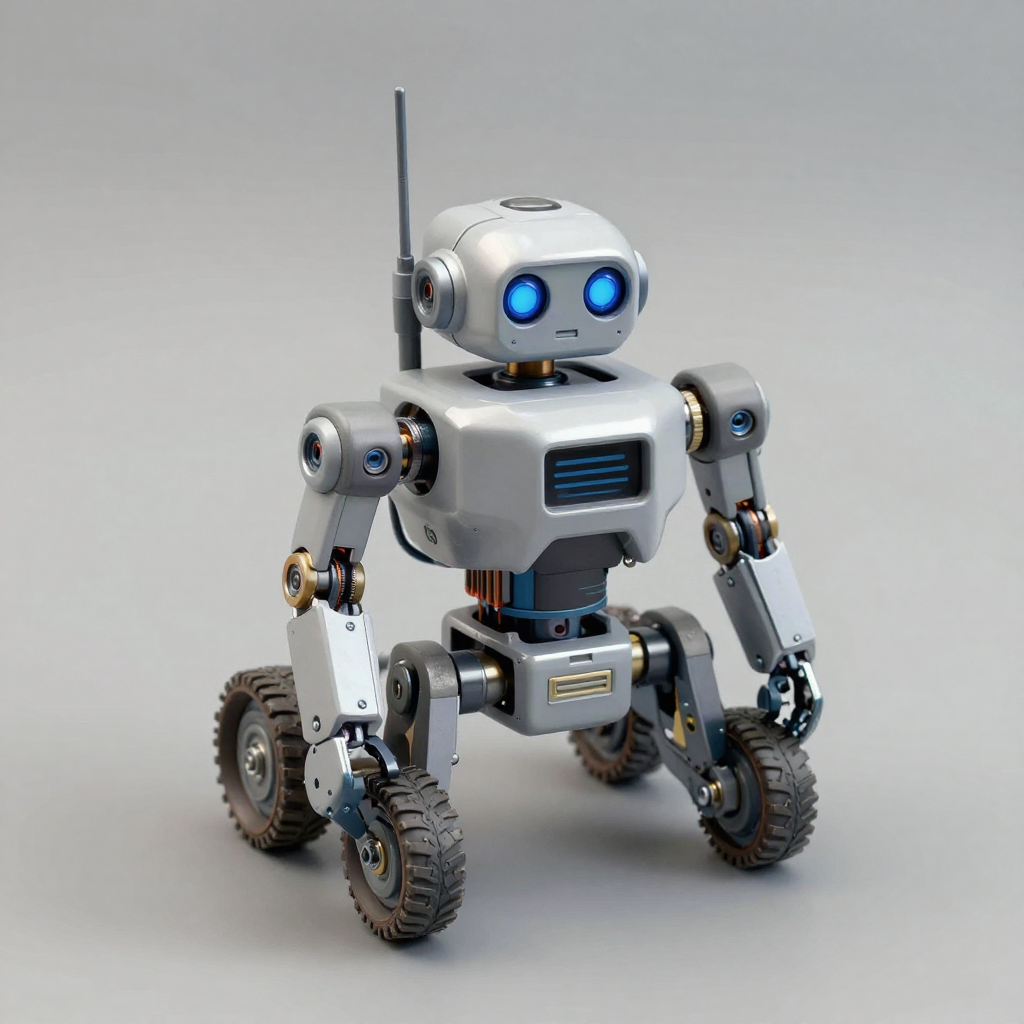

In [ ]:
out = generate(
    positive_prompt="mini robot, highly detailed, no background",
    steps=9,
    cfg=1.0
)
Image.open(out)

  0%|          | 0/20 [00:00<?, ?it/s]

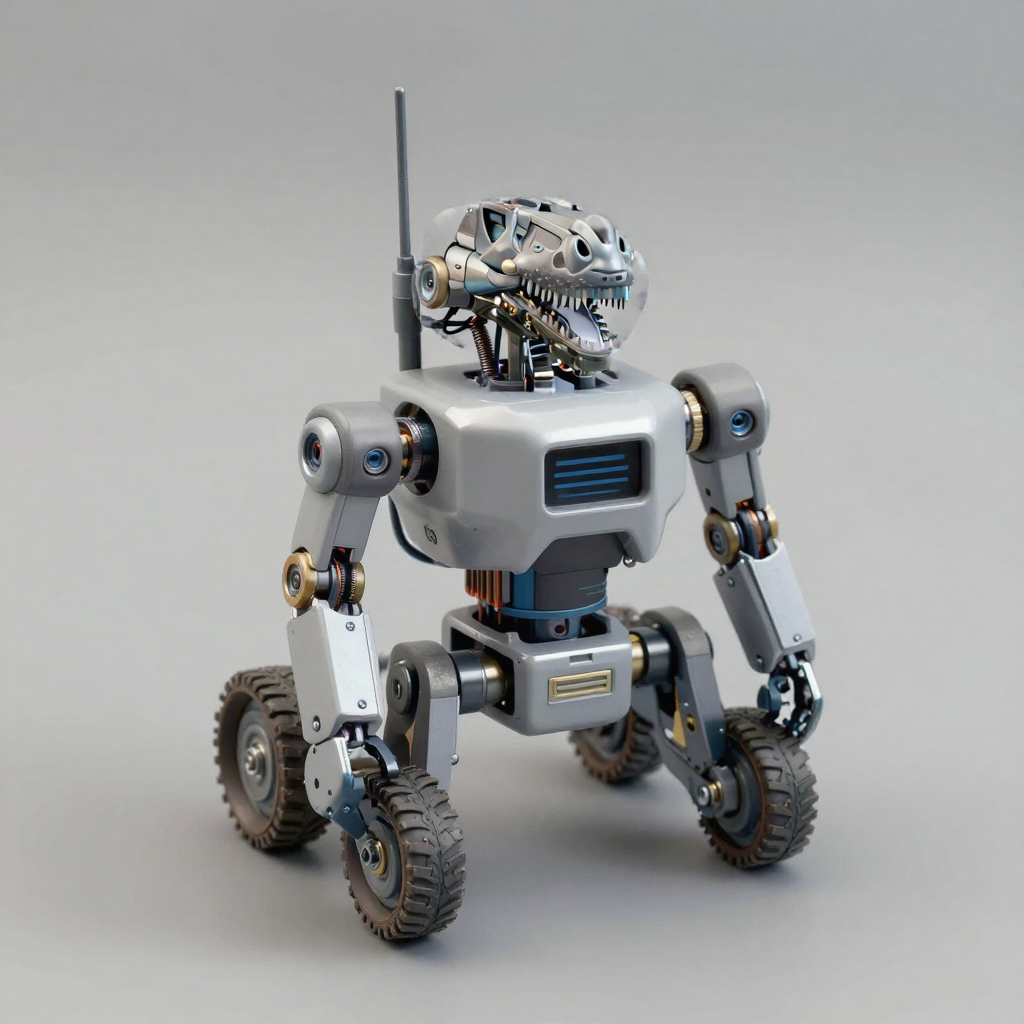

In [ ]:
out = inpaint(
    image_path      = "/content/ComfyUI/output/z_image_turbo.png",
    mask_path       = "/content/drive/MyDrive/mask.png",
    positive_prompt = "a t-rex head, robotic style, highly deatailed",
    denoise         = 0.85
)
Image.open(out)